# 04 - Đóng gói Model cho Production

**Mục tiêu:**
- Load dữ liệu đã tiền xử lý từ thư mục `../processed/` (được sinh ra ở Notebook 02).
- Huấn luyện lại model Random Forest tốt nhất trên toàn bộ tập train đã tiền xử lý.
- Load `scaler` và `imputer` đã đóng gói từ Notebook 02.
- Đóng gói toàn bộ model, scaler, imputer vào thư mục `../backend/assets/`.
- Viết code Verify để đảm bảo hệ thống có thể chạy dự đoán đúng.

## Import thư viện

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import joblib
import json
import os
import shutil
import warnings
warnings.filterwarnings("ignore")
print("Import thư viện thành công!")

Import thư viện thành công!


## Section 1: Load dữ liệu đã tiền xử lý
Chúng ta load lại dữ liệu train và test đã được chuẩn hóa ở Notebook 02.

In [17]:
train_prep = pd.read_csv("../processed/train_preprocessed.csv")
test_prep = pd.read_csv("../processed/test_preprocessed.csv")

X_train_scaled = train_prep.drop("Outcome", axis=1)
y_train_scaled = train_prep["Outcome"]
X_test_scaled = test_prep.drop("Outcome", axis=1)
y_test_scaled = test_prep["Outcome"]

print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")

Train shape: (614, 8)
Test shape: (154, 8)


## Section 2: Train model cuối cùng
Sử dụng siêu tham số tốt nhất đã tìm thấy ở Notebook 03.

In [18]:
best_params = {
    "n_estimators": 300,
    "max_depth": 15,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "class_weight": "balanced",
    "criterion": "entropy"
}

best_model = RandomForestClassifier(**best_params)
best_model.fit(X_train_scaled, y_train_scaled)
print("Đã huấn luyện xong mô hình Random Forest tốt nhất!")

Đã huấn luyện xong mô hình Random Forest tốt nhất!


## Section 3: Đánh giá mô hình trên Test set

In [19]:
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test_scaled, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test_scaled, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       100
           1       0.67      0.65      0.66        54

    accuracy                           0.77       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154

ROC-AUC: 0.8265


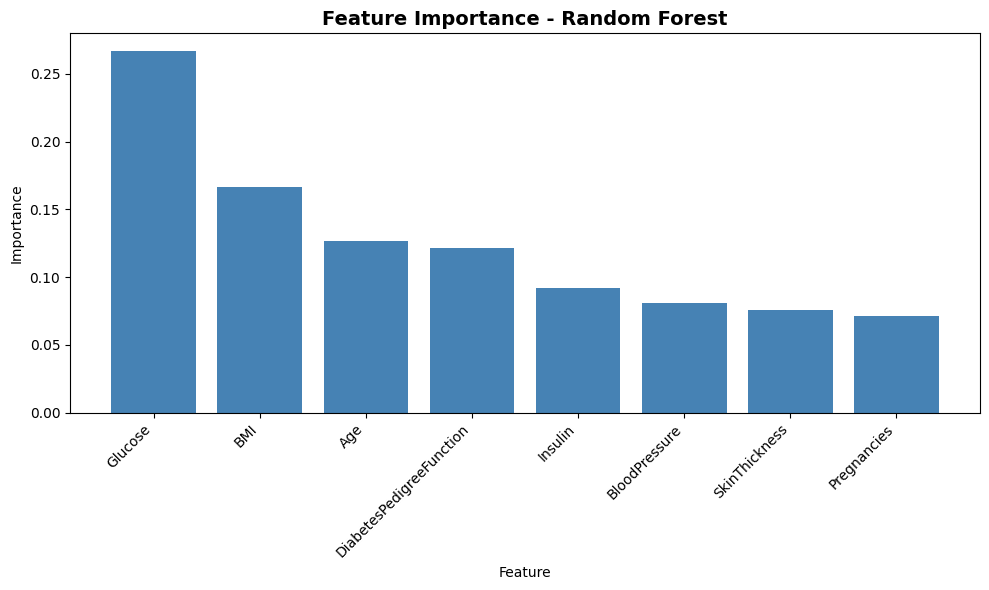

In [20]:
importances = best_model.feature_importances_
feature_names = X_train_scaled.columns
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[sorted_idx], color="steelblue")
plt.xticks(range(len(importances)), feature_names[sorted_idx], rotation=45, ha="right")
plt.title("Feature Importance - Random Forest", fontsize=14, fontweight="bold")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## Section 4: Đóng gói Model, Scaler và Imputer
Chúng ta sẽ copy `scaler.pkl` và `imputer_median.pkl` từ thư mục `../processed/` sang `../backend/assets/`, đồng thời lưu `diabetes_model.pkl` vào đó.
Chúng ta cũng tính toán `reference_stats.json` dựa trên dữ liệu thô để dùng cho vẽ Radar Chart ở giao diện frontend.

In [ ]:
SAVE_DIR = "../backend/assets"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Save model
joblib.dump(best_model, os.path.join(SAVE_DIR, "diabetes_model.pkl"))
print("Saved: diabetes_model.pkl")

# 2. Copy scaler & imputer từ processed sang backend/assets
shutil.copy("../processed/scaler.pkl", os.path.join(SAVE_DIR, "scaler.pkl"))
print("Copied: scaler.pkl")

shutil.copy("../processed/imputer_median.pkl", os.path.join(SAVE_DIR, "imputer_median.pkl"))
print("Copied: imputer_median.pkl")

# 3. Save reference stats (median của raw dataset)
df_raw = pd.read_csv("../data/raw/diabetes.csv")
X_raw = df_raw.drop("Outcome", axis=1)
reference_stats = X_raw.median().to_dict()
with open(os.path.join(SAVE_DIR, "reference_stats.json"), "w") as f:
    json.dump(reference_stats, f, indent=4)
print("Saved: reference_stats.json")

print(f"\nTất cả files đã có mặt trong: {SAVE_DIR}/")

Saved: diabetes_model.pkl
Copied: scaler.pkl
Copied: imputer_median.pkl
Saved: reference_stats.json

Tất cả files đã có mặt trong: ../backend/assets/


## Section 5: Verify - Load lại toàn bộ Pipeline và test 1 mẫu thô

In [ ]:
print("=== VERIFY: Load lại model và test ===")

# Load lại
loaded_model = joblib.load(os.path.join(SAVE_DIR, "diabetes_model.pkl"))
loaded_scaler = joblib.load(os.path.join(SAVE_DIR, "scaler.pkl"))
loaded_imputer = joblib.load(os.path.join(SAVE_DIR, "imputer_median.pkl"))

# Test với 1 mẫu thô
df_raw = pd.read_csv("../data/raw/diabetes.csv")
sample_raw = df_raw.iloc[0:1].drop("Outcome", axis=1).copy()
actual_outcome = df_raw.iloc[0]["Outcome"]

print(f"\n🔍 Test sample (raw):")
display(sample_raw)

# Áp dụng Pipeline tiền xử lý
cols_to_impute = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
sample_processed = sample_raw.copy()
for col in cols_to_impute:
    sample_processed[col] = sample_processed[col].replace(0, np.nan)

sample_imputed = pd.DataFrame(
    loaded_imputer.transform(sample_processed),
    columns=sample_raw.columns
)
sample_scaled = loaded_scaler.transform(sample_imputed)

# Dự đoán
prediction = loaded_model.predict(sample_scaled)
probability = loaded_model.predict_proba(sample_scaled)

res = "Diabetes" if prediction[0] == 1 else "No Diabetes"
print(f"🎯 Prediction: {prediction[0]} ({res})")
print(f"📊 Probability: No Diabetes={probability[0][0]:.4f}, Diabetes={probability[0][1]:.4f}")
print(f"📋 Actual Outcome: {actual_outcome}")
print("\n✅ Pipeline hoạt động trơn tru!")

=== VERIFY: Load lại model và test ===

🔍 Test sample (raw):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50


🎯 Prediction: 1 (Diabetes)
📊 Probability: No Diabetes=0.1666, Diabetes=0.8334
📋 Actual Outcome: 1.0

✅ Pipeline hoạt động trơn tru!


## Kết luận
- Toàn bộ Model, Scaler, và Imputer đã được đóng gói thành công.
- Pipeline đã được phân tách rõ ràng, Backend sẽ sử dụng các files `.pkl` này để cung cấp API dự đoán cho Frontend.